# Module 1 — From Linear Models to Deep Learning
## End-to-End Machine Learning Demo with Scikit-learn
**Applied AI Mastery Program** | Rina Buoy, PhD

---

| Section | Topic |
|---------|-------|
| §1 | Math Foundations — `Y = WXᵀ + w₀` |
| §2 | Input Encoding — categorical (one-hot, ordinal, binary) + numeric (StandardScaler, MinMaxScaler) |
| §3A–D | Regression — LinearRegression, Ridge (L2), Lasso (L1), ElasticNet |
| §3E | Hyperparameter Tuning — GridSearchCV + K-Fold CV |
| §3F | Regression Evaluation — MSE, MAE, R² |
| §4A–B | Binary Classification — Logistic Regression (no reg / L1 / L2) |
| §4C–F | Classification Evaluation — Confusion Matrix, Precision, Recall, F1, ROC-AUC |
| §5 | Multiclass — Softmax (Multinomial Logistic Regression) |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

from sklearn.datasets import fetch_california_housing, load_breast_cancer, load_iris
from sklearn.model_selection import (
    train_test_split, GridSearchCV, KFold, StratifiedKFold
)
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
)
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score, classification_report
)
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')
print('✓ All libraries imported successfully!')

✓ All libraries imported successfully!


---
## §1  Math Foundations — `Y = WXᵀ + w₀`
> **Slides 4–14** — A linear model is a matrix multiplication between weight matrix **W** and transposed feature matrix **Xᵀ**, plus a bias **w₀**.
>
> - **Linear Regression**: activation = identity `f(x) = x` (slide 24)
> - **Logistic Regression**: activation = sigmoid `g(z) = 1/(1+e⁻ᶻ)` (slide 28)
> - **Softmax Classifier**: activation = softmax (slide 29–31)


X  shape: (4, 3)  (n_samples × m_features)
W  shape: (2, 3)  (k_outputs × m_features)
w0 shape: (2,) (k_outputs,)
Y  shape: (4, 2)  (n_samples × k_outputs)

Y (4 samples, 2 outputs):
[[12.4 25.6]
 [13.  26.5]
 [11.7 24.8]
 [13.3 26.7]]

Verify Y[0,0]: [0.5 0.2 0.1] · [2 4 6] + 10 = 12.4  ✓


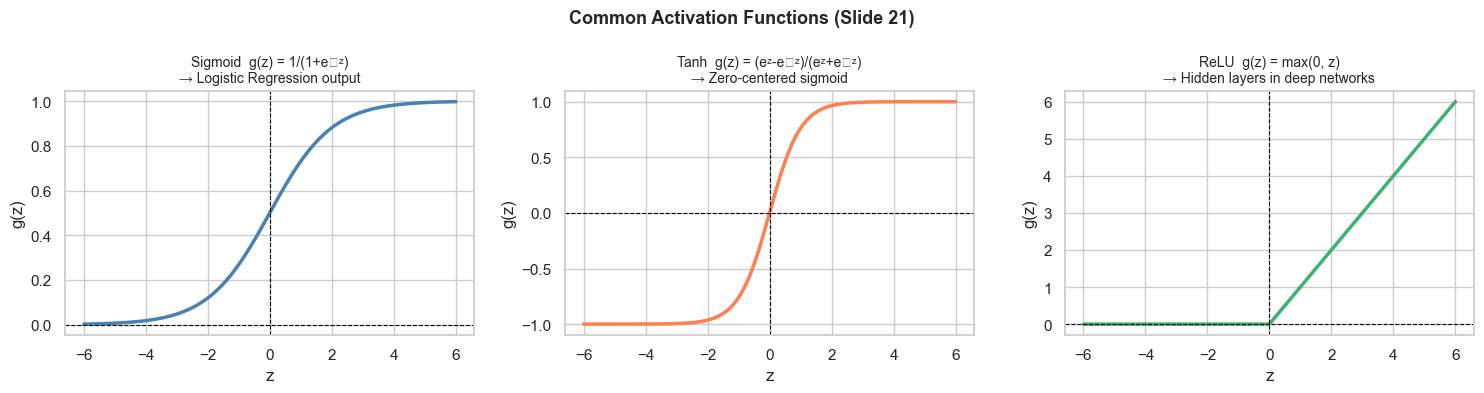

In [2]:
# ── Slide 12 example ──────────────────────────────────────────────────────────
# X: (4 samples, 3 features)   W: (2 outputs, 3 features)   w0: (2 outputs,)

X = np.array([[2, 4, 6],
              [5, 1, 3],
              [1, 2, 8],
              [3, 7, 4]])      # shape (4, 3)

W  = np.array([[0.5, 0.2, 0.1],
               [1.0, 0.3, 0.4]])  # shape (2, 3)
w0 = np.array([10, 20])           # shape (2,)

# Y = W @ X.T + w0  → broadcast w0 along n dimension
Y = (W @ X.T).T + w0              # shape (4, 2)

print(f'X  shape: {X.shape}  (n_samples × m_features)')
print(f'W  shape: {W.shape}  (k_outputs × m_features)')
print(f'w0 shape: {w0.shape} (k_outputs,)')
print(f'Y  shape: {Y.shape}  (n_samples × k_outputs)')
print(f'\nY (4 samples, 2 outputs):\n{Y}')

# Manual verification sample 1, output 1
check = W[0] @ X[0] + w0[0]
print(f'\nVerify Y[0,0]: {W[0]} · {X[0]} + {w0[0]} = {check}  ✓')

# ── Sigmoid (logistic) and softmax for intuition ───────────────────────────
z = np.linspace(-6, 6, 200)
sigmoid = 1 / (1 + np.exp(-z))
relu    = np.maximum(0, z)
tanh_z  = np.tanh(z)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, y_vals, name, color in [
    (axes[0], sigmoid, 'Sigmoid  g(z) = 1/(1+e⁻ᶻ)\n→ Logistic Regression output', 'steelblue'),
    (axes[1], tanh_z,  'Tanh  g(z) = (eᶻ-e⁻ᶻ)/(eᶻ+e⁻ᶻ)\n→ Zero-centered sigmoid',  'coral'),
    (axes[2], relu,    'ReLU  g(z) = max(0, z)\n→ Hidden layers in deep networks', 'mediumseagreen'),
]:
    ax.plot(z, y_vals, color=color, lw=2.5)
    ax.axhline(0, color='black', lw=0.8, linestyle='--')
    ax.axvline(0, color='black', lw=0.8, linestyle='--')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('z')
    ax.set_ylabel('g(z)')

plt.suptitle('Common Activation Functions (Slide 21)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## §2  Pre-Processing
> **Slides 34–37** — Before feeding data into any linear model, we must convert all inputs to numbers.
>
> | Input type | Encoding method | sklearn class |
> |------------|-----------------|---------------|
> | Nominal (no order) | One-hot / Dummy | `OneHotEncoder` |
> | Ordinal (has order) | Integer map | `OrdinalEncoder` |
> | Binary | 0/1 | manual or `LabelEncoder` |
> | Numeric | StandardScaler (z-score) | `StandardScaler` |
> | Numeric | Min-Max | `MinMaxScaler` |


In [3]:
# ── §2.1  Categorical Encoding (Slide 35) ─────────────────────────────────────

demo = pd.DataFrame({
    'color':    ['Red', 'Green', 'Blue', 'Red', 'Green', 'Blue'],
    'quality':  ['Poor', 'Good', 'Excellent', 'Very Good', 'Good', 'Poor'],
    'has_pool': ['Yes', 'No', 'Yes', 'No', 'Yes', 'No'],
})
print('Original:')
print(demo, '\n')

# 1. One-Hot Encoding  (nominal — no natural order)
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
color_ohe = pd.DataFrame(
    ohe.fit_transform(demo[['color']]),
    columns=ohe.get_feature_names_out(['color'])
)
print('1. One-Hot Encoding (color — nominal):')
print(color_ohe, '\n')

# 2. Dummy Encoding  (drop first category to avoid multicollinearity)
ohe_d = OneHotEncoder(sparse_output=False, drop='first')
color_dummy = pd.DataFrame(
    ohe_d.fit_transform(demo[['color']]),
    columns=ohe_d.get_feature_names_out(['color'])
)
print('2. Dummy Encoding (drop="first" removes one column):')
print(color_dummy, '\n')

# 3. Ordinal Encoding  (ordinal — Poor < Good < Very Good < Excellent)
oe = OrdinalEncoder(categories=[['Poor', 'Good', 'Very Good', 'Excellent']])
quality_oe = oe.fit_transform(demo[['quality']])
print('3. Ordinal Encoding (quality — ordered):')
print(pd.DataFrame({'quality': demo['quality'], 'encoded': quality_oe.flatten()}), '\n')

# 4. Binary Encoding
demo['has_pool_binary'] = (demo['has_pool'] == 'Yes').astype(int)
print('4. Binary Encoding (has_pool):')
print(demo[['has_pool', 'has_pool_binary']])


Original:
   color    quality has_pool
0    Red       Poor      Yes
1  Green       Good       No
2   Blue  Excellent      Yes
3    Red  Very Good       No
4  Green       Good      Yes
5   Blue       Poor       No 

1. One-Hot Encoding (color — nominal):
   color_Blue  color_Green  color_Red
0         0.0          0.0        1.0
1         0.0          1.0        0.0
2         1.0          0.0        0.0
3         0.0          0.0        1.0
4         0.0          1.0        0.0
5         1.0          0.0        0.0 

2. Dummy Encoding (drop="first" removes one column):
   color_Green  color_Red
0          0.0        1.0
1          1.0        0.0
2          0.0        0.0
3          0.0        1.0
4          1.0        0.0
5          0.0        0.0 

3. Ordinal Encoding (quality — ordered):
     quality  encoded
0       Poor      0.0
1       Good      1.0
2  Excellent      3.0
3  Very Good      2.0
4       Good      1.0
5       Poor      0.0 

4. Binary Encoding (has_pool):
  has_pool  h

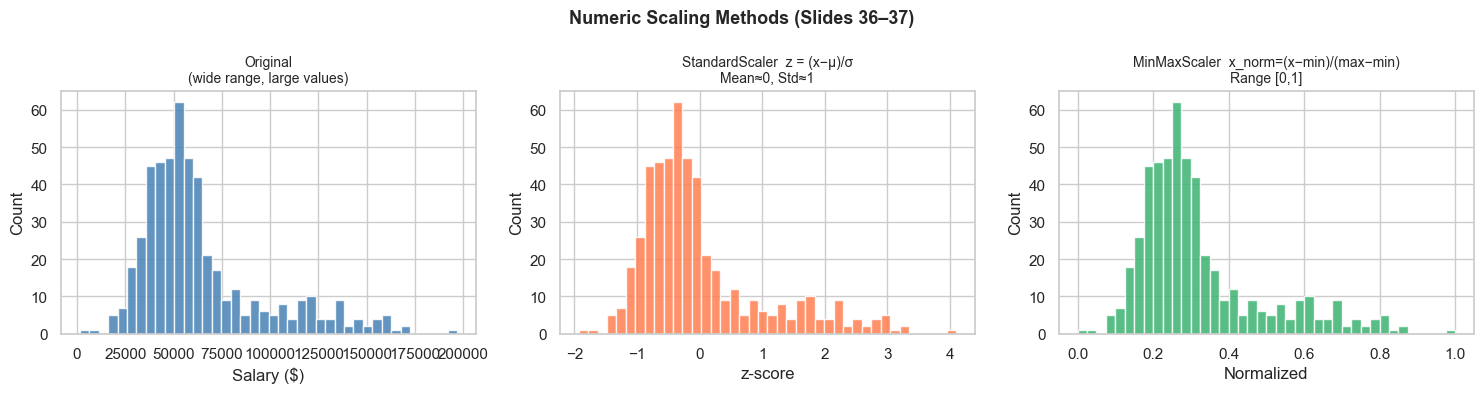

StandardScaler → mean: -0.00000, std: 1.0000
MinMaxScaler   → min:  0.0000, max: 1.0000


In [4]:
# ── §2.2  Numeric Scaling (Slides 36–37) ──────────────────────────────────────

np.random.seed(42)
salaries = np.concatenate([
    np.random.normal(50_000, 15_000, 400),
    np.random.normal(120_000, 25_000, 100)
]).clip(0).reshape(-1, 1)

std_scaler = StandardScaler()   # z = (x - μ) / σ
mm_scaler  = MinMaxScaler()     # x_norm = (x - x_min) / (x_max - x_min)

sal_std = std_scaler.fit_transform(salaries)
sal_mm  = mm_scaler.fit_transform(salaries)

configs = [
    (salaries.flatten(), 'Original\n(wide range, large values)', 'Salary ($)', 'steelblue'),
    (sal_std.flatten(),  'StandardScaler  z = (x−μ)/σ\nMean≈0, Std≈1',  'z-score',   'coral'),
    (sal_mm.flatten(),   'MinMaxScaler  x_norm=(x−min)/(max−min)\nRange [0,1]', 'Normalized', 'mediumseagreen'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (data, title, xlabel, color) in zip(axes, configs):
    ax.hist(data, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')

plt.suptitle('Numeric Scaling Methods (Slides 36–37)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'StandardScaler → mean: {sal_std.mean():.5f}, std: {sal_std.std():.4f}')
print(f'MinMaxScaler   → min:  {sal_mm.min():.4f}, max: {sal_mm.max():.4f}')


---
## §3  Regression — California Housing Dataset
> Predicting **median house value** ($100K) from 8 numeric + 2 synthetic categorical features.
>
> | Model | Regularization | Loss function |
> |-------|---------------|---------------|
> | `LinearRegression` | None | MSE = (1/n)Σ(yᵢ − ŷᵢ)² |
> | `Ridge` | L2: λΣwᵢ² | MSE + λΣwᵢ² |
> | `Lasso` | L1: λΣ\|wᵢ\| | MSE + λΣ\|wᵢ\| |
> | `ElasticNet` | L1 + L2 | MSE + λ[r·L1 + (1−r)·L2] |


In [5]:
# ── Load + enrich dataset ──────────────────────────────────────────────────────
housing = fetch_california_housing(as_frame=True)
df_reg  = housing.frame.copy()

np.random.seed(42)
n = len(df_reg)

df_reg['neighborhood_quality'] = np.random.choice(
    ['budget', 'standard', 'premium'], size=n, p=[0.30, 0.50, 0.20]
)
df_reg['property_type'] = np.random.choice(
    ['apartment', 'house', 'condo'], size=n, p=[0.40, 0.40, 0.20]
)
# add small signal so categoricals correlate with target
bonus = {'budget': -0.15, 'standard': 0.0, 'premium': 0.28}
df_reg['MedHouseVal'] = (df_reg['MedHouseVal'] +
                          df_reg['neighborhood_quality'].map(bonus)).clip(lower=0.5)

print(f'Shape: {df_reg.shape}')
print(f'\nData types:\n{df_reg.dtypes}')
print(f'\nTarget stats:')
print(df_reg['MedHouseVal'].describe().round(3))


Shape: (20640, 11)

Data types:
MedInc                  float64
HouseAge                float64
AveRooms                float64
AveBedrms               float64
Population              float64
AveOccup                float64
Latitude                float64
Longitude               float64
MedHouseVal             float64
neighborhood_quality     object
property_type            object
dtype: object

Target stats:
count    20640.000
mean         2.082
std          1.163
min          0.500
25%          1.211
50%          1.813
75%          2.662
max          5.280
Name: MedHouseVal, dtype: float64


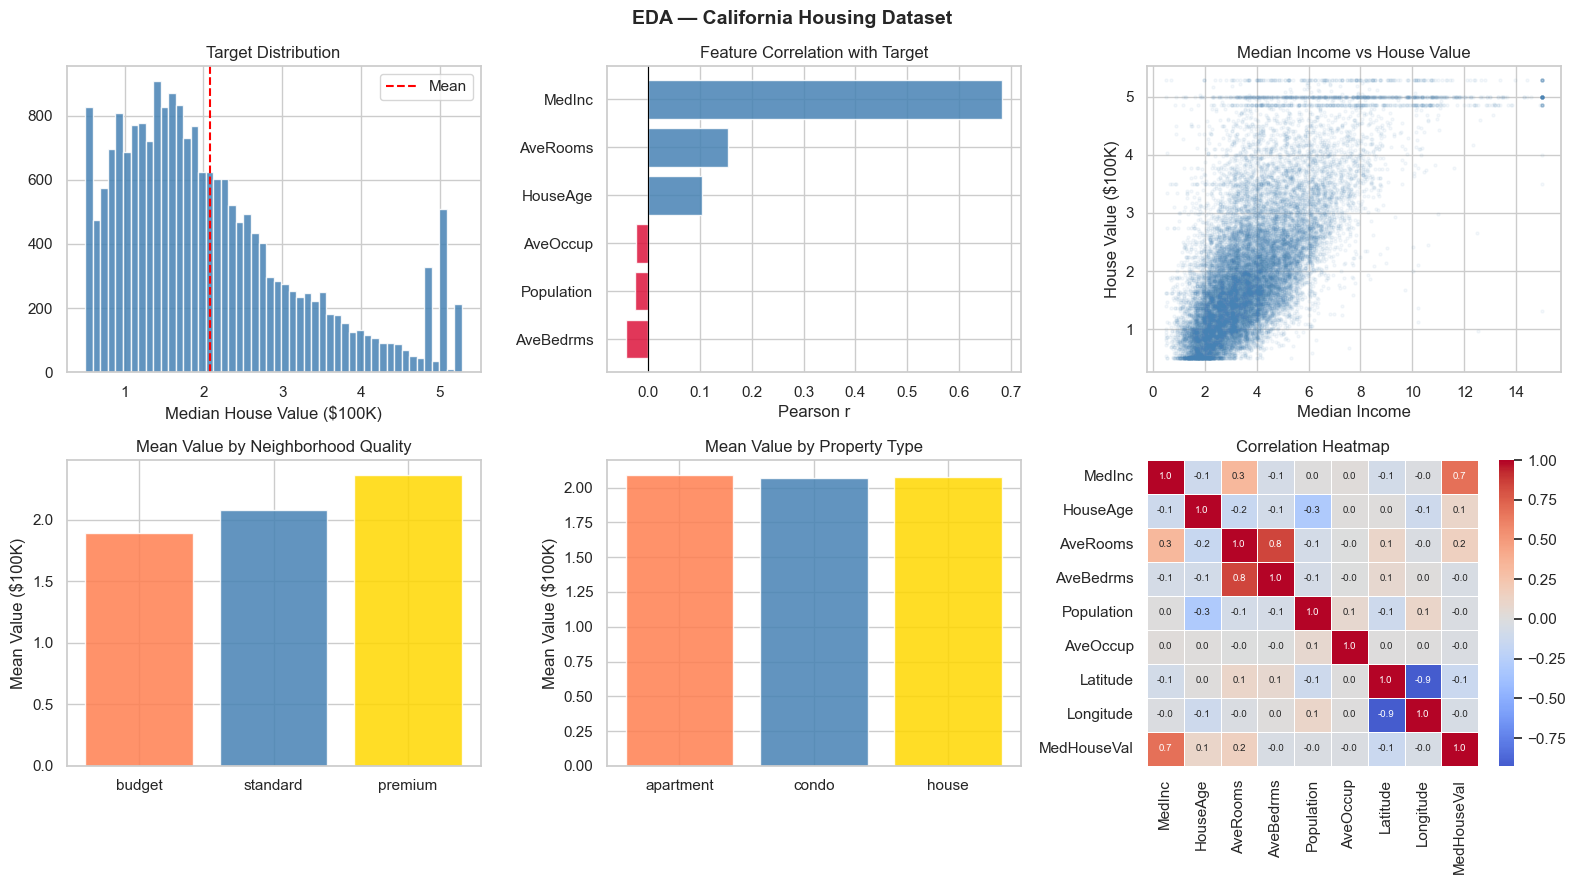

In [6]:
# ── EDA ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Target distribution
axes[0,0].hist(df_reg['MedHouseVal'], bins=50, color='steelblue',
               edgecolor='white', alpha=0.85)
axes[0,0].axvline(df_reg['MedHouseVal'].mean(), color='red', ls='--', label='Mean')
axes[0,0].set_title('Target Distribution')
axes[0,0].set_xlabel('Median House Value ($100K)')
axes[0,0].legend()

# Correlation bar
num_feats = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
corrs = df_reg[num_feats + ['MedHouseVal']].corr()['MedHouseVal'][:-1].sort_values()
bar_colors = ['crimson' if c < 0 else 'steelblue' for c in corrs]
axes[0,1].barh(corrs.index, corrs.values, color=bar_colors, edgecolor='white', alpha=0.85)
axes[0,1].axvline(0, color='black', lw=0.8)
axes[0,1].set_title('Feature Correlation with Target')
axes[0,1].set_xlabel('Pearson r')

# Scatter: MedInc vs target
axes[0,2].scatter(df_reg['MedInc'], df_reg['MedHouseVal'],
                  alpha=0.05, color='steelblue', s=5)
axes[0,2].set_title('Median Income vs House Value')
axes[0,2].set_xlabel('Median Income')
axes[0,2].set_ylabel('House Value ($100K)')

# Categorical: neighborhood quality
nq = df_reg.groupby('neighborhood_quality')['MedHouseVal'].mean() \
           .reindex(['budget', 'standard', 'premium'])
axes[1,0].bar(nq.index, nq.values, color=['coral','steelblue','gold'],
              edgecolor='white', alpha=0.85)
axes[1,0].set_title('Mean Value by Neighborhood Quality')
axes[1,0].set_ylabel('Mean Value ($100K)')

# Categorical: property type
pt = df_reg.groupby('property_type')['MedHouseVal'].mean()
axes[1,1].bar(pt.index, pt.values, color=['coral','steelblue','gold'],
              edgecolor='white', alpha=0.85)
axes[1,1].set_title('Mean Value by Property Type')
axes[1,1].set_ylabel('Mean Value ($100K)')

# Heatmap
num_cols = df_reg.select_dtypes(include=[np.number]).columns
sns.heatmap(df_reg[num_cols].corr(), annot=True, fmt='.1f',
            cmap='coolwarm', center=0, ax=axes[1,2],
            annot_kws={'size': 7}, linewidths=0.4)
axes[1,2].set_title('Correlation Heatmap')

plt.suptitle('EDA — California Housing Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [7]:
# ── Feature definitions + preprocessing ───────────────────────────────────────
numeric_feats  = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                  'Population', 'AveOccup', 'Latitude', 'Longitude']
nominal_feats  = ['neighborhood_quality', 'property_type']

X_reg = df_reg[numeric_feats + nominal_feats]
y_reg = df_reg['MedHouseVal']

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
print(f'Train: {X_tr_r.shape}  |  Test: {X_te_r.shape}')

preprocessor_r = ColumnTransformer(transformers=[
    ('num', StandardScaler(),                                       numeric_feats),
    ('nom', OneHotEncoder(drop='first', handle_unknown='ignore'),   nominal_feats),
], remainder='drop')

preprocessor_r.fit(X_tr_r)
X_tr_r_t = preprocessor_r.transform(X_tr_r)
X_te_r_t  = preprocessor_r.transform(X_te_r)

print('\nPreprocessor:')
print('  numeric → StandardScaler')
print('  nominal → OneHotEncoder(drop="first")  [dummy encoding]')

# ── Helper ────────────────────────────────────────────────────────────────────
def eval_reg(model, Xtr, ytr, Xte, yte, name):
    model.fit(Xtr, ytr)
    return {
        'Model':     name,
        'Train R²':  r2_score(ytr,  model.predict(Xtr)),
        'Test R²':   r2_score(yte,  model.predict(Xte)),
        'Train MSE': mean_squared_error(ytr, model.predict(Xtr)),
        'Test MSE':  mean_squared_error(yte, model.predict(Xte)),
        'Train MAE': mean_absolute_error(ytr, model.predict(Xtr)),
        'Test MAE':  mean_absolute_error(yte, model.predict(Xte)),
    }

reg_results = []

Train: (16512, 10)  |  Test: (4128, 10)

Preprocessor:
  numeric → StandardScaler
  nominal → OneHotEncoder(drop="first")  [dummy encoding]


§3A  Linear Regression
  Train R²=0.6194  Test R²=0.5841
  Train MSE=0.5165  Test MSE=0.5547


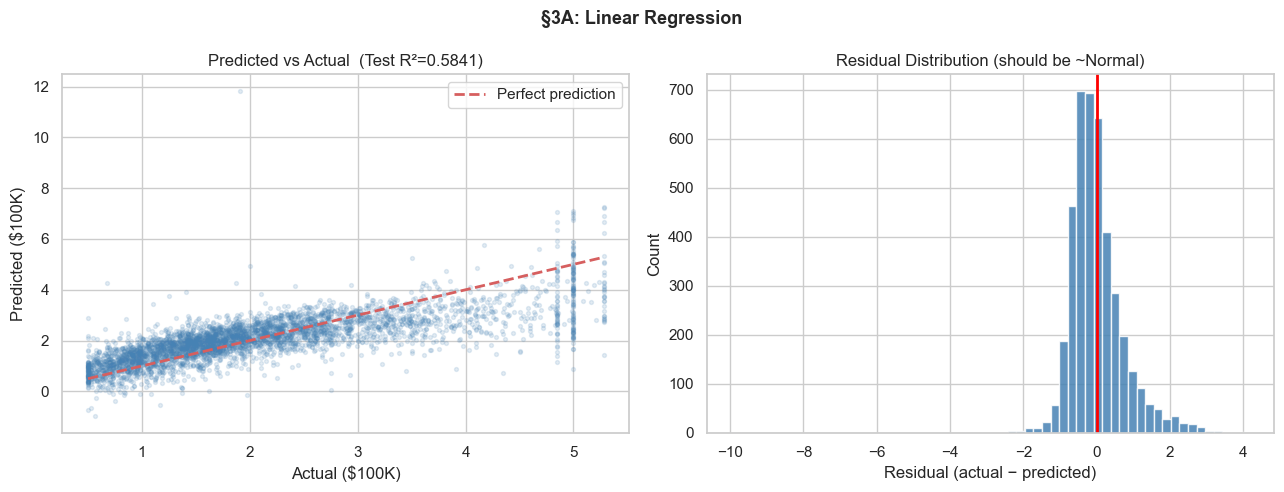

In [8]:
# ── §3A  Linear Regression (Slide 24) ─────────────────────────────────────────
# y = WXᵀ + w₀  |  identity activation  |  Loss: MSE

lr = LinearRegression()
m_lr = eval_reg(lr, X_tr_r_t, y_tr_r, X_te_r_t, y_te_r, 'LinearRegression')
reg_results.append(m_lr)

print('§3A  Linear Regression')
print(f"  Train R²={m_lr['Train R²']:.4f}  Test R²={m_lr['Test R²']:.4f}")
print(f"  Train MSE={m_lr['Train MSE']:.4f}  Test MSE={m_lr['Test MSE']:.4f}")

y_pred_lr = lr.predict(X_te_r_t)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lim = [y_te_r.min(), y_te_r.max()]
axes[0].scatter(y_te_r, y_pred_lr, alpha=0.15, color='steelblue', s=8)
axes[0].plot(lim, lim, 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual ($100K)')
axes[0].set_ylabel('Predicted ($100K)')
axes[0].set_title(f'Predicted vs Actual  (Test R²={m_lr["Test R²"]:.4f})')
axes[0].legend()

residuals = y_te_r - y_pred_lr
axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', lw=2)
axes[1].set_xlabel('Residual (actual − predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution (should be ~Normal)')

plt.suptitle('§3A: Linear Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# ── §3B  Ridge Regression — L2 Regularization (Slide 60) ─────────────────────
# Loss = MSE + λ·Σwᵢ²   (alpha = λ)
# Coefficients shrink towards zero but never become exactly zero

ridge = Ridge(alpha=1.0)
m_ridge = eval_reg(ridge, X_tr_r_t, y_tr_r, X_te_r_t, y_te_r, 'Ridge (α=1.0)')
reg_results.append(m_ridge)

print('§3B  Ridge Regression (L2)')
print(f"  Train R²={m_ridge['Train R²']:.4f}  Test R²={m_ridge['Test R²']:.4f}")
print(f"  Train MSE={m_ridge['Train MSE']:.4f}  Test MSE={m_ridge['Test MSE']:.4f}")
print('  → All coefficients remain non-zero (continuous shrinkage)')

§3B  Ridge Regression (L2)
  Train R²=0.6194  Test R²=0.5842
  Train MSE=0.5165  Test MSE=0.5546
  → All coefficients remain non-zero (continuous shrinkage)


In [10]:
# ── §3C  Lasso Regression — L1 Regularization (Slide 60) ─────────────────────
# Loss = MSE + λ·Σ|wᵢ|   → produces sparsity (feature selection)

lasso = Lasso(alpha=0.01, max_iter=10_000)
m_lasso = eval_reg(lasso, X_tr_r_t, y_tr_r, X_te_r_t, y_te_r, 'Lasso (α=0.01)')
reg_results.append(m_lasso)

n_zero = int(np.sum(np.abs(lasso.coef_) < 1e-8))

print('§3C  Lasso Regression (L1)')
print(f"  Train R²={m_lasso['Train R²']:.4f}  Test R²={m_lasso['Test R²']:.4f}")
print(f"  Coefficients zeroed out: {n_zero}/{len(lasso.coef_)}  ← automatic feature selection!")

§3C  Lasso Regression (L1)
  Train R²=0.6137  Test R²=0.5886
  Coefficients zeroed out: 3/12  ← automatic feature selection!


In [11]:
# ── §3D  ElasticNet — L1 + L2 Regularization ─────────────────────────────────
# Loss = MSE + λ·[l1_ratio·Σ|wᵢ| + (1−l1_ratio)·Σwᵢ²]

enet = ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10_000)
m_enet = eval_reg(enet, X_tr_r_t, y_tr_r, X_te_r_t, y_te_r, 'ElasticNet (α=0.01,r=0.5)')
reg_results.append(m_enet)

print('§3D  ElasticNet (L1 + L2)')
print(f"  Train R²={m_enet['Train R²']:.4f}  Test R²={m_enet['Test R²']:.4f}")
print('  l1_ratio=0.5 → equal mix of Lasso sparsity and Ridge shrinkage')

§3D  ElasticNet (L1 + L2)
  Train R²=0.6163  Test R²=0.5882
  l1_ratio=0.5 → equal mix of Lasso sparsity and Ridge shrinkage


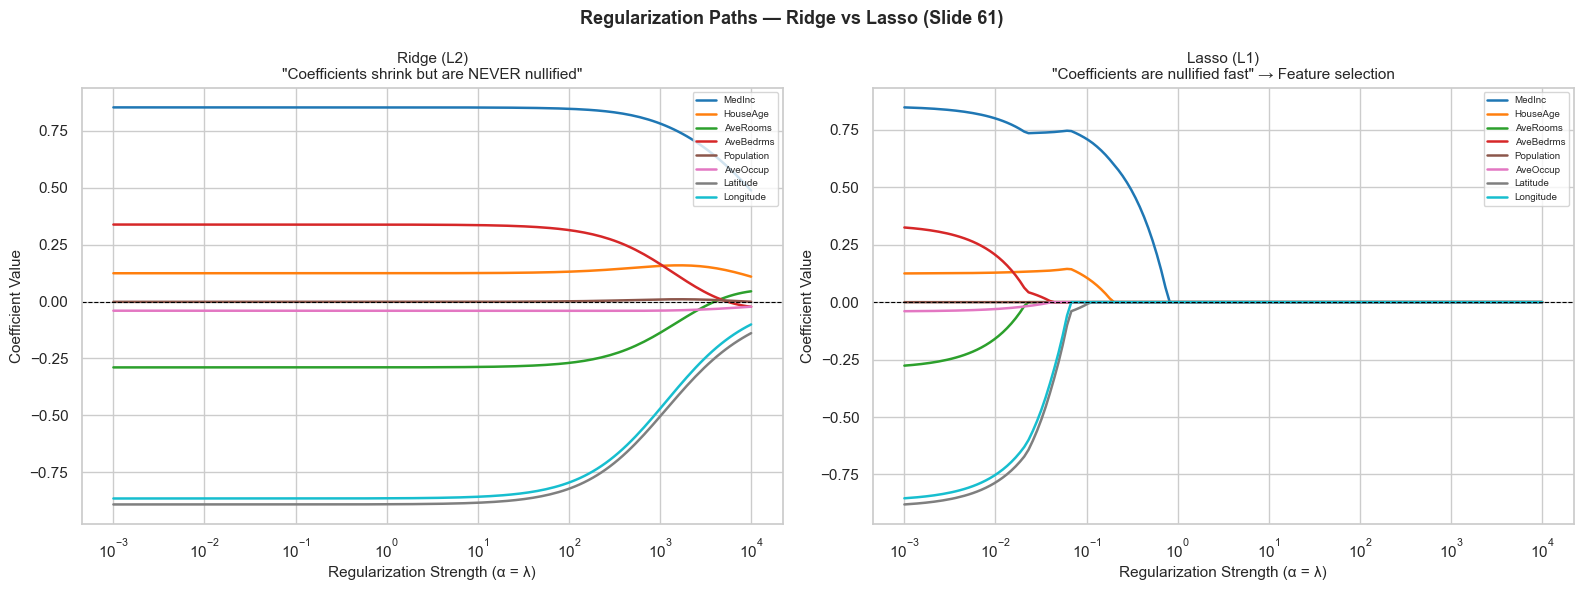

In [12]:
# ── Regularization Paths: Ridge vs Lasso (Slide 61) ──────────────────────────
# Shows how coefficients change as regularization strength (alpha) increases

sc_path = StandardScaler()
X_path  = sc_path.fit_transform(X_tr_r[numeric_feats])

alphas_path   = np.logspace(-3, 4, 150)
ridge_path = np.array([Ridge(alpha=a).fit(X_path, y_tr_r).coef_
                        for a in alphas_path])
lasso_path = np.array([Lasso(alpha=a, max_iter=10_000).fit(X_path, y_tr_r).coef_
                        for a in alphas_path])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
palette = plt.cm.tab10(np.linspace(0, 0.9, len(numeric_feats)))

for i, (feat, c) in enumerate(zip(numeric_feats, palette)):
    ax1.plot(alphas_path, ridge_path[:, i], color=c, label=feat, lw=1.8)
    ax2.plot(alphas_path, lasso_path[:, i], color=c, label=feat, lw=1.8)

for ax, title in [
    (ax1, 'Ridge (L2)\n"Coefficients shrink but are NEVER nullified"'),
    (ax2, 'Lasso (L1)\n"Coefficients are nullified fast" → Feature selection'),
]:
    ax.set_xscale('log')
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_xlabel('Regularization Strength (α = λ)', fontsize=11)
    ax.set_ylabel('Coefficient Value', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Regularization Paths — Ridge vs Lasso (Slide 61)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### §3E  Hyperparameter Tuning
> **Slides 62–63** — Use K-Fold cross-validation on the training set to pick the best `alpha` (λ).
> The test set is **never touched** during tuning — it is only used for the final generalization estimate.
>
> ```
> GridSearchCV  →  tries every alpha in param_grid
>   └── KFold(k=5)  →  for each alpha, trains on 4 folds, validates on 1
>                       repeats 5 times, averages validation score
> ```


Best alpha: 1.0
Best CV RMSE: 0.7200
Test R²:  0.5842
Test RMSE: 0.7447


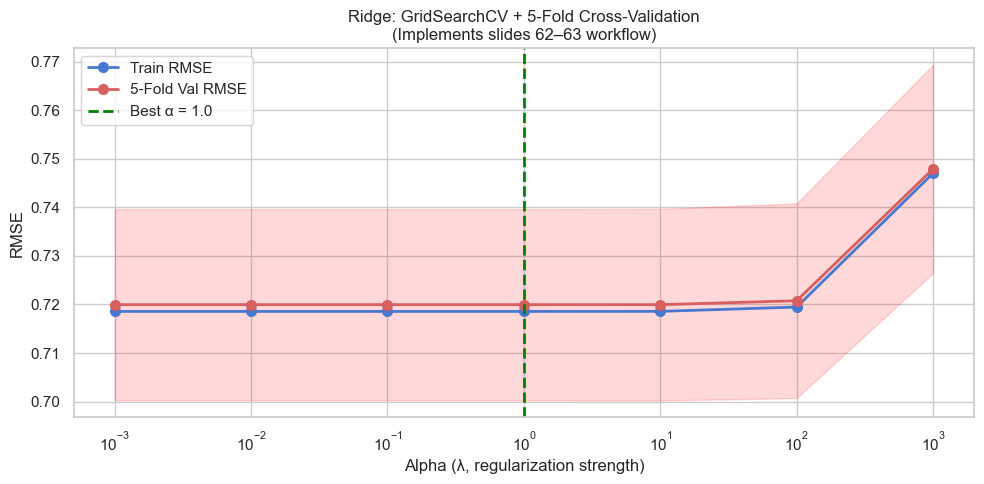

In [13]:
# ── GridSearchCV: Ridge ───────────────────────────────────────────────────────
param_grid_ridge = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}

ridge_gs = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid_ridge,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_mean_squared_error',
    return_train_score=True,
    n_jobs=-1
)
ridge_gs.fit(X_tr_r_t, y_tr_r)

best_alpha_r = ridge_gs.best_params_['alpha']
cv_r = pd.DataFrame(ridge_gs.cv_results_)

print(f'Best alpha: {best_alpha_r}')
print(f'Best CV RMSE: {np.sqrt(-ridge_gs.best_score_):.4f}')
y_pred_ridge_gs = ridge_gs.predict(X_te_r_t)
print(f'Test R²:  {r2_score(y_te_r, y_pred_ridge_gs):.4f}')
print(f'Test RMSE: {np.sqrt(mean_squared_error(y_te_r, y_pred_ridge_gs)):.4f}')

# Visualise train vs validation across alpha
alphas_cv = cv_r['param_alpha'].astype(float)
train_rmse = np.sqrt(-cv_r['mean_train_score'])
val_rmse   = np.sqrt(-cv_r['mean_test_score'])
val_std    = cv_r['std_test_score']

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(alphas_cv, train_rmse, 'b-o', label='Train RMSE', lw=2, markersize=7)
ax.semilogx(alphas_cv, val_rmse,   'r-o', label='5-Fold Val RMSE', lw=2, markersize=7)
ax.fill_between(alphas_cv, val_rmse - val_std, val_rmse + val_std,
                alpha=0.15, color='red')
ax.axvline(best_alpha_r, color='green', ls='--', lw=2,
            label=f'Best α = {best_alpha_r}')
ax.set_xlabel('Alpha (λ, regularization strength)', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('Ridge: GridSearchCV + 5-Fold Cross-Validation\n(Implements slides 62–63 workflow)',
             fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# ── GridSearchCV: Lasso + ElasticNet ─────────────────────────────────────────
lasso_gs = GridSearchCV(
    Lasso(max_iter=20_000),
    param_grid={'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]},
    cv=KFold(5, shuffle=True, random_state=42),
    scoring='neg_mean_squared_error', n_jobs=-1
)
lasso_gs.fit(X_tr_r_t, y_tr_r)
best_alpha_l = lasso_gs.best_params_['alpha']
print(f'Best Lasso alpha: {best_alpha_l}')

enet_gs = GridSearchCV(
    ElasticNet(max_iter=20_000),
    param_grid={'alpha': [0.001, 0.01, 0.1, 1.0],
                'l1_ratio': [0.2, 0.5, 0.8]},
    cv=KFold(5, shuffle=True, random_state=42),
    scoring='neg_mean_squared_error', n_jobs=-1
)
enet_gs.fit(X_tr_r_t, y_tr_r)
print(f'Best ElasticNet params: {enet_gs.best_params_}')

# Append tuned results
reg_results.append({
    'Model': f'Ridge (tuned α={best_alpha_r})',
    'Train R²':  r2_score(y_tr_r, ridge_gs.predict(X_tr_r_t)),
    'Test R²':   r2_score(y_te_r, ridge_gs.predict(X_te_r_t)),
    'Train MSE': mean_squared_error(y_tr_r, ridge_gs.predict(X_tr_r_t)),
    'Test MSE':  mean_squared_error(y_te_r, ridge_gs.predict(X_te_r_t)),
    'Train MAE': mean_absolute_error(y_tr_r, ridge_gs.predict(X_tr_r_t)),
    'Test MAE':  mean_absolute_error(y_te_r, ridge_gs.predict(X_te_r_t)),
})
reg_results.append({
    'Model': f'Lasso (tuned α={best_alpha_l})',
    'Train R²':  r2_score(y_tr_r, lasso_gs.predict(X_tr_r_t)),
    'Test R²':   r2_score(y_te_r, lasso_gs.predict(X_te_r_t)),
    'Train MSE': mean_squared_error(y_tr_r, lasso_gs.predict(X_tr_r_t)),
    'Test MSE':  mean_squared_error(y_te_r, lasso_gs.predict(X_te_r_t)),
    'Train MAE': mean_absolute_error(y_tr_r, lasso_gs.predict(X_tr_r_t)),
    'Test MAE':  mean_absolute_error(y_te_r, lasso_gs.predict(X_te_r_t)),
})

Best Lasso alpha: 0.001
Best ElasticNet params: {'alpha': 0.001, 'l1_ratio': 0.8}


=== Regression Results ===
                           Train R²  Test R²  Train MSE  Test MSE  Overfit Gap (R²)
Model                                                                              
LinearRegression             0.6194   0.5841     0.5165    0.5547            0.0352
Ridge (α=1.0)                0.6194   0.5842     0.5165    0.5546            0.0352
Lasso (α=0.01)               0.6137   0.5886     0.5242    0.5487            0.0251
ElasticNet (α=0.01,r=0.5)    0.6163   0.5882     0.5207    0.5492            0.0281
Ridge (tuned α=1.0)          0.6194   0.5842     0.5165    0.5546            0.0352
Lasso (tuned α=0.001)        0.6193   0.5853     0.5166    0.5532            0.0340


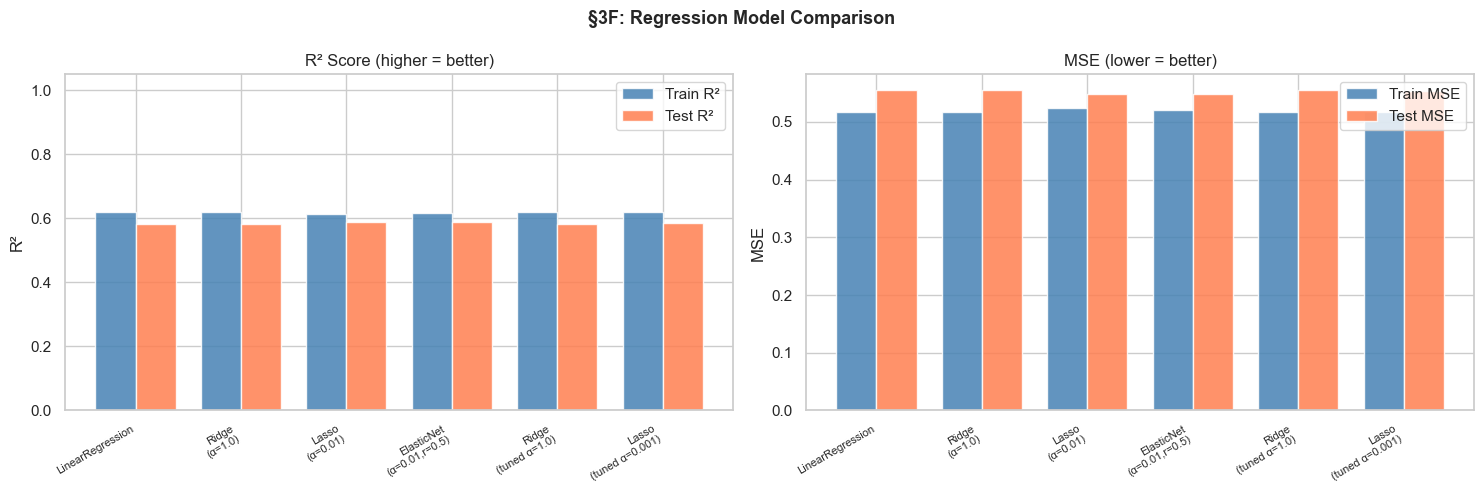


Small Train/Test gap → good generalisation (no severe overfitting)


In [15]:
# ── §3F  Regression Model Comparison ─────────────────────────────────────────
results_df = pd.DataFrame(reg_results).set_index('Model')
results_df['Overfit Gap (R²)'] = (results_df['Train R²'] - results_df['Test R²']).round(4)
print('=== Regression Results ===')
print(results_df[['Train R²','Test R²','Train MSE','Test MSE','Overfit Gap (R²)']]
      .round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x   = np.arange(len(results_df))
w   = 0.38
lbls = [m.replace(' (', '\n(') for m in results_df.index]

axes[0].bar(x - w/2, results_df['Train R²'], w, label='Train R²', color='steelblue', alpha=0.85)
axes[0].bar(x + w/2, results_df['Test R²'],  w, label='Test R²',  color='coral',     alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(lbls, rotation=30, ha='right', fontsize=8)
axes[0].set_ylabel('R²'); axes[0].set_title('R² Score (higher = better)')
axes[0].legend(); axes[0].set_ylim(0, 1.05)

axes[1].bar(x - w/2, results_df['Train MSE'], w, label='Train MSE', color='steelblue', alpha=0.85)
axes[1].bar(x + w/2, results_df['Test MSE'],  w, label='Test MSE',  color='coral',     alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(lbls, rotation=30, ha='right', fontsize=8)
axes[1].set_ylabel('MSE'); axes[1].set_title('MSE (lower = better)')
axes[1].legend()

plt.suptitle('§3F: Regression Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('\nSmall Train/Test gap → good generalisation (no severe overfitting)')


---
## §4  Binary Classification — Breast Cancer Dataset
> Predicting **Malignant (1)** vs **Benign (0)** from 30 numeric + 2 synthetic categorical features.
>
> **Logistic Regression** = linear layer + **sigmoid** activation (slide 28):
> `ŷ = sigmoid(WXᵀ + w₀) = 1 / (1 + e⁻⁽ᵂˣ⁺ʷ⁰⁾)`
>
> **Loss: Binary Cross-Entropy** (slide 41–43):
> `L = -(1/n) Σ [ yᵢ log(pᵢ) + (1−yᵢ) log(1−pᵢ) ]`


In [16]:
bc     = load_breast_cancer(as_frame=True)
df_clf = bc.frame.copy()
# sklearn encodes 0=malignant, 1=benign; flip so 1=malignant (positive class)
df_clf['target'] = 1 - df_clf['target']

np.random.seed(42)
n_c = len(df_clf)
df_clf['patient_history'] = np.random.choice(
    ['none', 'mild', 'severe'], size=n_c, p=[0.50, 0.35, 0.15]
)
df_clf['biopsy_type'] = np.random.choice(
    ['FNA', 'core', 'excisional'], size=n_c, p=[0.45, 0.35, 0.20]
)

print(f'Shape: {df_clf.shape}')
vc = df_clf['target'].value_counts().rename({0:'Benign',1:'Malignant'})
print(f'\nClass distribution:\n{vc}')
print(f'Positive rate: {df_clf["target"].mean():.1%} malignant')


Shape: (569, 33)

Class distribution:
target
Benign       357
Malignant    212
Name: count, dtype: int64
Positive rate: 37.3% malignant


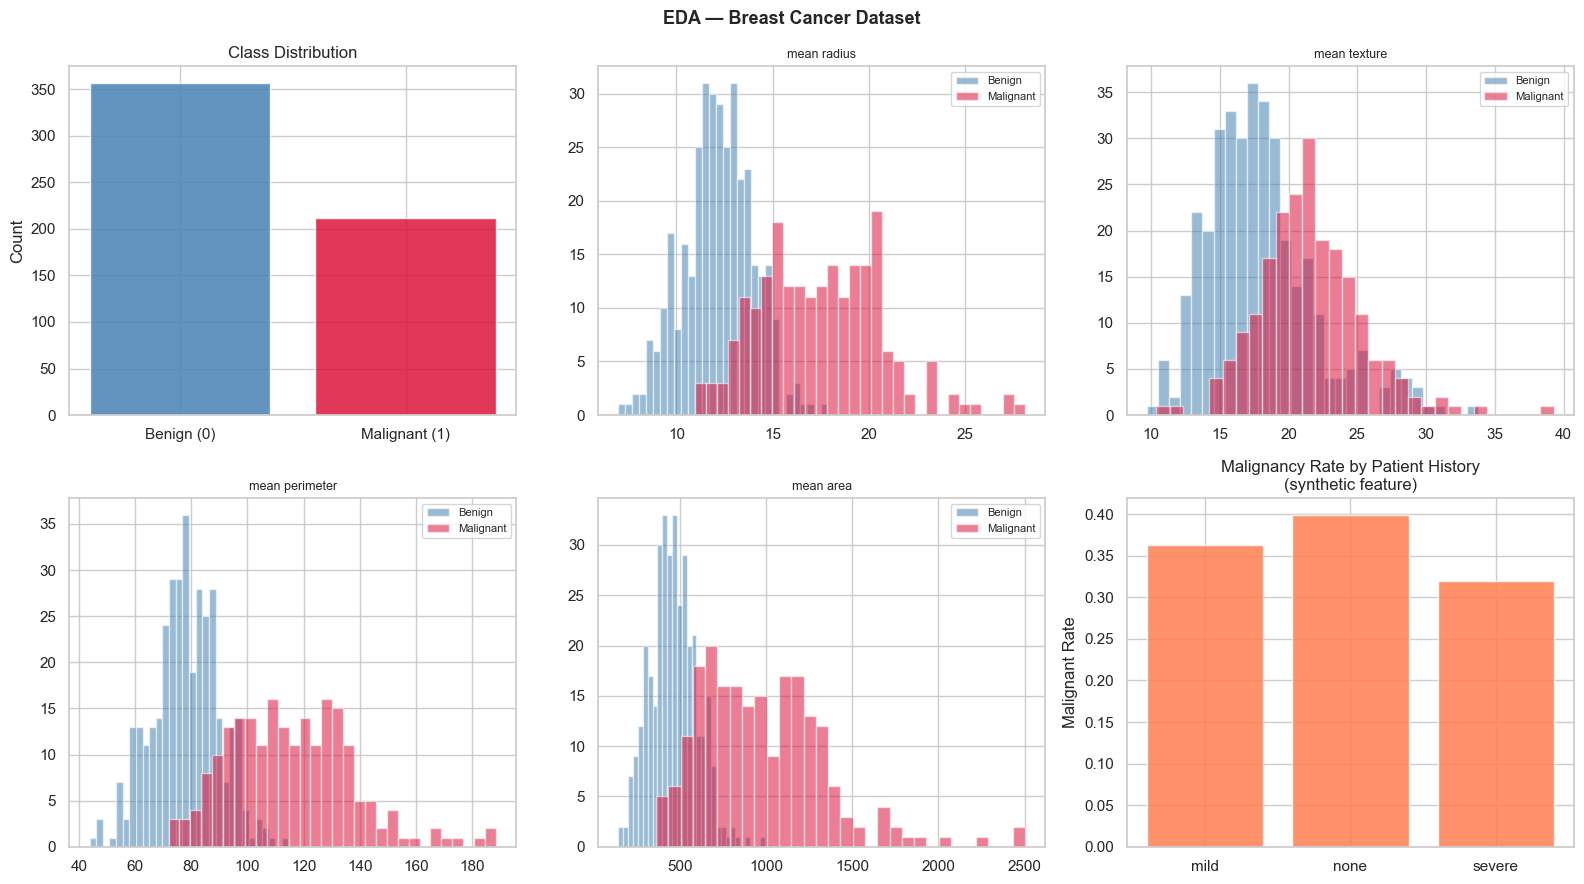

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Class counts
axes[0,0].bar(['Benign (0)','Malignant (1)'],
               df_clf['target'].value_counts().sort_index().values,
               color=['steelblue','crimson'], edgecolor='white', alpha=0.85)
axes[0,0].set_title('Class Distribution')
axes[0,0].set_ylabel('Count')

top4 = list(bc.feature_names[:4])
for i, feat in enumerate(top4):
    ax = axes[(i+1)//3, (i+1)%3]
    for cls, color, label in [(0,'steelblue','Benign'),(1,'crimson','Malignant')]:
        ax.hist(df_clf[df_clf['target']==cls][feat],
                bins=30, alpha=0.55, color=color, label=label, edgecolor='white')
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=8)

ph = df_clf.groupby('patient_history')['target'].mean()
axes[1,2].bar(ph.index, ph.values, color='coral', edgecolor='white', alpha=0.85)
axes[1,2].set_title('Malignancy Rate by Patient History\n(synthetic feature)')
axes[1,2].set_ylabel('Malignant Rate')

plt.suptitle('EDA — Breast Cancer Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [18]:
clf_num_feats = [str(f) for f in bc.feature_names]   # explicit str() guards against numpy.str_ / StringDType in numpy 2.x
clf_nom_feats = ['biopsy_type']
clf_ord_feats = ['patient_history']

X_clf = df_clf[clf_num_feats + clf_nom_feats + clf_ord_feats]
y_clf = df_clf['target']

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
print(f'Train: {X_tr_c.shape}  |  Test: {X_te_c.shape}')
print(f'Train malignant: {y_tr_c.mean():.1%}  |  Test malignant: {y_te_c.mean():.1%}')

preprocessor_c = ColumnTransformer(transformers=[
    ('num', StandardScaler(),                                                clf_num_feats),
    ('nom', OneHotEncoder(drop='first', handle_unknown='ignore'),            clf_nom_feats),
    ('ord', OrdinalEncoder(categories=[['none','mild','severe']]),           clf_ord_feats),
], remainder='drop')

preprocessor_c.fit(X_tr_c)
X_tr_c_t = preprocessor_c.transform(X_tr_c)
X_te_c_t  = preprocessor_c.transform(X_te_c)

print('\nPreprocessor:')
print('  30 numeric features   → StandardScaler')
print('  biopsy_type (nominal) → OneHotEncoder(drop=first)')
print('  patient_history (ord) → OrdinalEncoder(none<mild<severe)')

Train: (455, 32)  |  Test: (114, 32)
Train malignant: 37.4%  |  Test malignant: 36.8%

Preprocessor:
  30 numeric features   → StandardScaler
  biopsy_type (nominal) → OneHotEncoder(drop=first)
  patient_history (ord) → OrdinalEncoder(none<mild<severe)


In [19]:
# ── §4A  Logistic Regression — No Regularization (Slide 28) ──────────────────
lr_no_reg = LogisticRegression(penalty=None, solver='lbfgs', max_iter=2000)
lr_no_reg.fit(X_tr_c_t, y_tr_c)

y_pred_base = lr_no_reg.predict(X_te_c_t)
y_prob_base = lr_no_reg.predict_proba(X_te_c_t)[:, 1]

print('§4A  Logistic Regression — No Regularization')
print(f'  Accuracy:  {accuracy_score(y_te_c,  y_pred_base):.4f}')
print(f'  Precision: {precision_score(y_te_c, y_pred_base):.4f}')
print(f'  Recall:    {recall_score(y_te_c,    y_pred_base):.4f}')
print(f'  F1:        {f1_score(y_te_c,        y_pred_base):.4f}')
print(f'  AUC-ROC:   {roc_auc_score(y_te_c,   y_prob_base):.4f}')

§4A  Logistic Regression — No Regularization
  Accuracy:  0.9298
  Precision: 0.8864
  Recall:    0.9286
  F1:        0.9070
  AUC-ROC:   0.9805


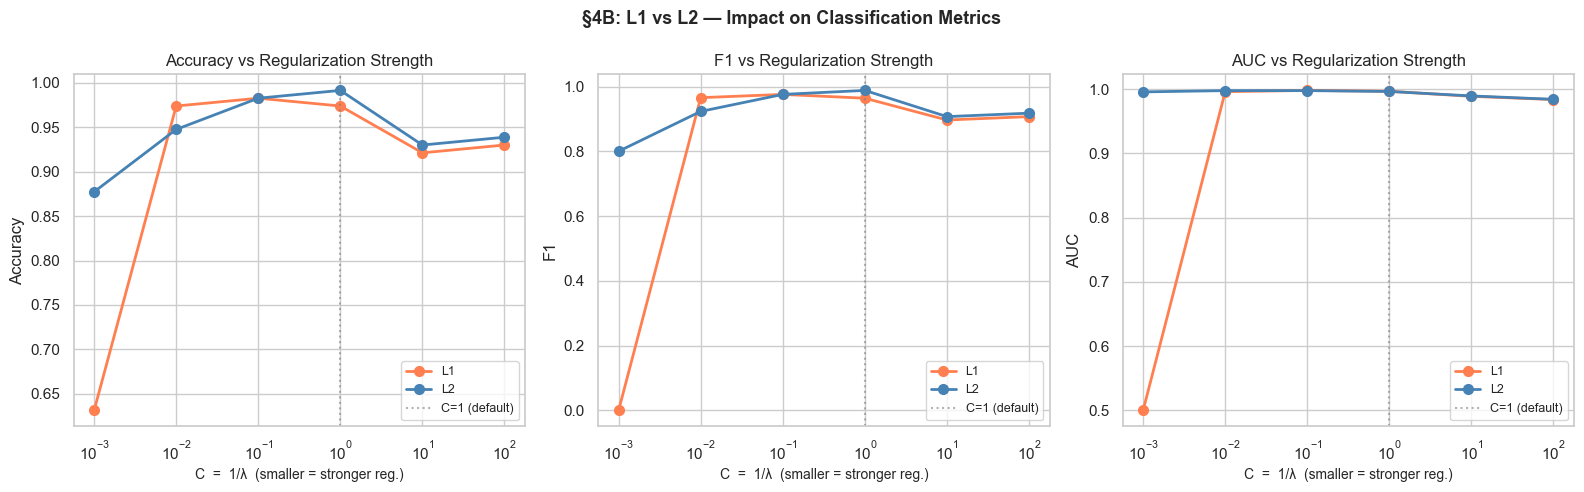

In [20]:
# ── §4B  L1 vs L2 Regularization — effect of C = 1/λ ─────────────────────────
# Note: C is the INVERSE of regularization strength. Smaller C → stronger regularization.

C_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
clf_sweep = []

for C in C_values:
    for penalty, solver in [('l2','lbfgs'), ('l1','liblinear')]:
        clf = LogisticRegression(penalty=penalty, C=C, solver=solver, max_iter=2000)
        clf.fit(X_tr_c_t, y_tr_c)
        yp  = clf.predict(X_te_c_t)
        ypr = clf.predict_proba(X_te_c_t)[:, 1]
        clf_sweep.append({
            'C': C, 'Penalty': penalty.upper(),
            'Accuracy':  accuracy_score(y_te_c,  yp),
            'F1':        f1_score(y_te_c,         yp),
            'AUC':       roc_auc_score(y_te_c,    ypr),
        })

sweep_df = pd.DataFrame(clf_sweep)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for metric, ax in zip(['Accuracy', 'F1', 'AUC'], axes):
    for penalty, color in [('L1','coral'), ('L2','steelblue')]:
        sub = sweep_df[sweep_df['Penalty'] == penalty]
        ax.semilogx(sub['C'], sub[metric], 'o-', color=color,
                     label=penalty, lw=2, markersize=7)
    ax.axvline(1.0, color='gray', ls=':', alpha=0.6, label='C=1 (default)')
    ax.set_xlabel('C  =  1/λ  (smaller = stronger reg.)', fontsize=10)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} vs Regularization Strength')
    ax.legend(fontsize=9)

plt.suptitle('§4B: L1 vs L2 — Impact on Classification Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Best C: 1.0
Best CV AUC: 0.9963
Test AUC: 0.9964
Test F1:  0.9880


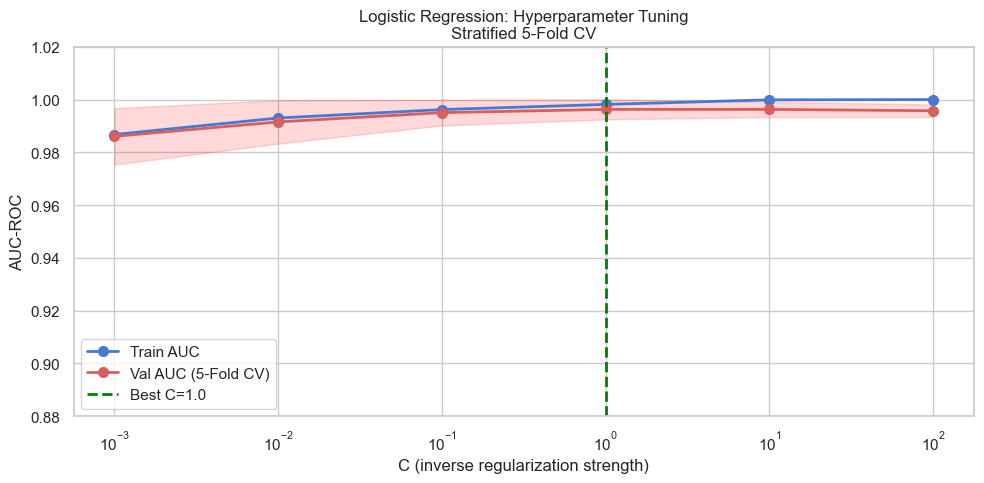

In [21]:
# ── §4C  GridSearchCV for Logistic Regression ─────────────────────────────────
lr_gs = GridSearchCV(
    LogisticRegression(penalty='l2', solver='lbfgs', max_iter=2000),
    param_grid={'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]},
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    return_train_score=True,
    n_jobs=-1
)
lr_gs.fit(X_tr_c_t, y_tr_c)

best_C = lr_gs.best_params_['C']
y_pred_tuned = lr_gs.predict(X_te_c_t)
y_prob_tuned = lr_gs.predict_proba(X_te_c_t)[:, 1]

print(f'Best C: {best_C}')
print(f'Best CV AUC: {lr_gs.best_score_:.4f}')
print(f'Test AUC: {roc_auc_score(y_te_c, y_prob_tuned):.4f}')
print(f'Test F1:  {f1_score(y_te_c, y_pred_tuned):.4f}')

cv_c = pd.DataFrame(lr_gs.cv_results_)
Cs   = cv_c['param_C'].astype(float)

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(Cs, cv_c['mean_train_score'], 'b-o', label='Train AUC', lw=2, markersize=7)
ax.semilogx(Cs, cv_c['mean_test_score'],  'r-o', label='Val AUC (5-Fold CV)', lw=2, markersize=7)
ax.fill_between(Cs,
                cv_c['mean_test_score'] - cv_c['std_test_score'],
                cv_c['mean_test_score'] + cv_c['std_test_score'],
                alpha=0.15, color='red')
ax.axvline(best_C, color='green', ls='--', lw=2, label=f'Best C={best_C}')
ax.set_xlabel('C (inverse regularization strength)', fontsize=12)
ax.set_ylabel('AUC-ROC', fontsize=12)
ax.set_title('Logistic Regression: Hyperparameter Tuning\nStratified 5-Fold CV', fontsize=12)
ax.legend()
ax.set_ylim(0.88, 1.02)
plt.tight_layout()
plt.show()

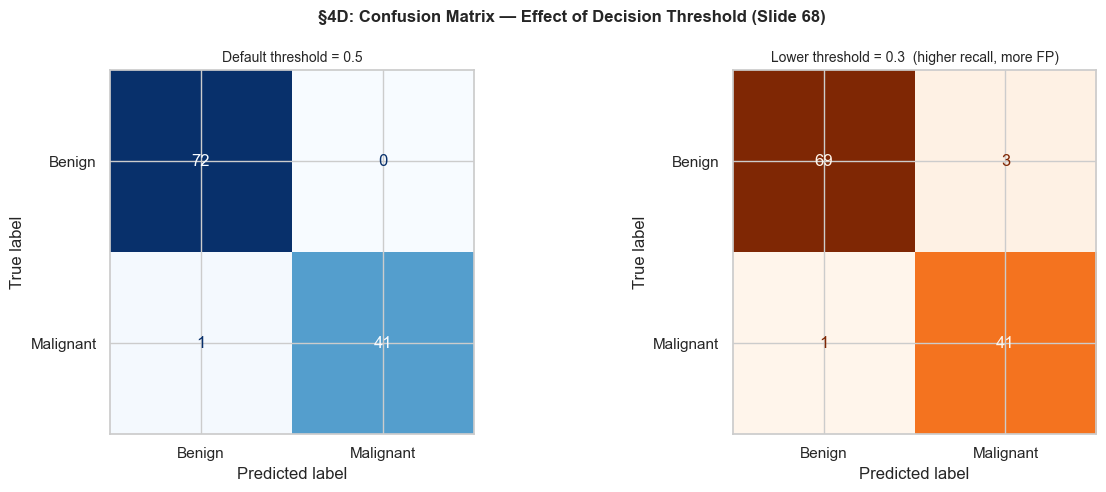

          Accuracy Precision  Recall      F1     FPR     FNR
Threshold                                                   
0.5         0.9912    1.0000  0.9762  0.9880  0.0000  0.0238
0.3         0.9649    0.9318  0.9762  0.9535  0.0417  0.0238


In [22]:
# ── §4D  Confusion Matrix (Slides 66–68) ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, thresh, cmap, title_suffix in [
    (axes[0], 0.5, 'Blues',   'Default threshold = 0.5'),
    (axes[1], 0.3, 'Oranges', 'Lower threshold = 0.3  (higher recall, more FP)'),
]:
    yp = (y_prob_tuned >= thresh).astype(int)
    cm = confusion_matrix(y_te_c, yp)
    ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Malignant']).plot(
        ax=ax, colorbar=False, cmap=cmap
    )
    ax.set_title(title_suffix, fontsize=10)

plt.suptitle('§4D: Confusion Matrix — Effect of Decision Threshold (Slide 68)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

rows = []
for thresh in [0.5, 0.3]:
    yp = (y_prob_tuned >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te_c, yp).ravel()
    rows.append({
        'Threshold': thresh,
        'Accuracy':  f'{accuracy_score(y_te_c, yp):.4f}',
        'Precision': f'{precision_score(y_te_c, yp):.4f}',
        'Recall':    f'{recall_score(y_te_c, yp):.4f}',
        'F1':        f'{f1_score(y_te_c, yp):.4f}',
        'FPR':       f'{fp/(fp+tn):.4f}',
        'FNR':       f'{fn/(fn+tp):.4f}',
    })
print(pd.DataFrame(rows).set_index('Threshold').to_string())


In [23]:
# ── §4E  Full Classification Report (Slide 67) ───────────────────────────────
print(f'Classification Report — Best Logistic Regression (L2, C={best_C})')
print('=' * 55)
print(classification_report(y_te_c, y_pred_tuned,
                             target_names=['Benign', 'Malignant']))


Classification Report — Best Logistic Regression (L2, C=1.0)
              precision    recall  f1-score   support

      Benign       0.99      1.00      0.99        72
   Malignant       1.00      0.98      0.99        42

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



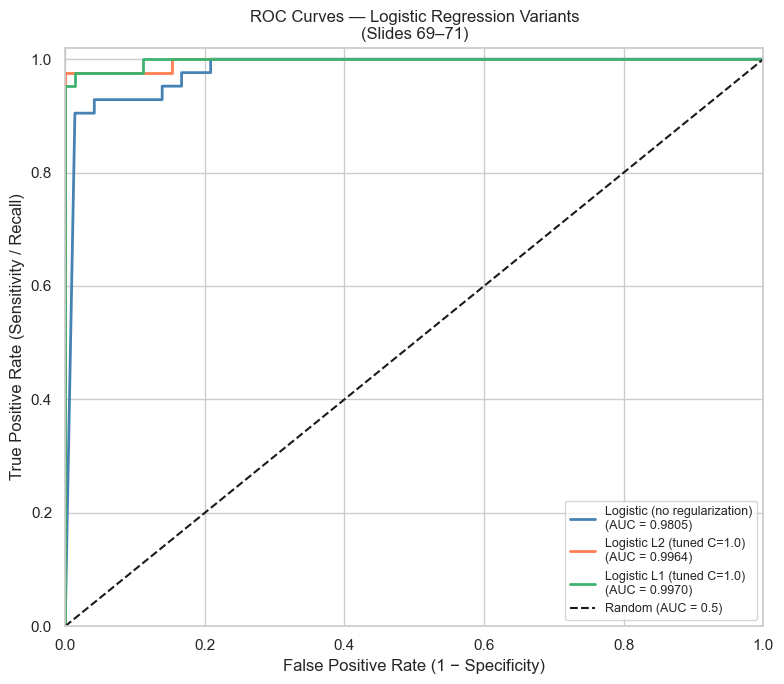

AUC Interpretation:
  1.0 = Perfect  |  0.9–1.0 = Excellent  |  0.8–0.9 = Good
  0.7–0.8 = Fair  |  0.5 = Random classifier (no skill)


In [24]:
# ── §4F  ROC Curves + AUC (Slides 69–71) ─────────────────────────────────────
# Tune L1 model too for comparison
lr_gs_l1 = GridSearchCV(
    LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000),
    param_grid={'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]},
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1
)
lr_gs_l1.fit(X_tr_c_t, y_tr_c)
y_prob_l1 = lr_gs_l1.predict_proba(X_te_c_t)[:, 1]

models_roc = {
    'Logistic (no regularization)': y_prob_base,
    f'Logistic L2 (tuned C={best_C})': y_prob_tuned,
    f'Logistic L1 (tuned C={lr_gs_l1.best_params_["C"]})': y_prob_l1,
}

fig, ax = plt.subplots(figsize=(8, 7))
colors_roc = ['steelblue', 'coral', 'mediumseagreen']

for (name, y_prob), color in zip(models_roc.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_te_c, y_prob)
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name}\n(AUC = {auc_val:.4f})')

ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate (1 − Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
ax.set_title('ROC Curves — Logistic Regression Variants\n(Slides 69–71)', fontsize=12)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.show()

print('AUC Interpretation:')
print('  1.0 = Perfect  |  0.9–1.0 = Excellent  |  0.8–0.9 = Good')
print('  0.7–0.8 = Fair  |  0.5 = Random classifier (no skill)')

---
## §5  Multiclass Classification — Softmax / Multinomial Logistic Regression
> **Slides 29–31** — For K classes the output activation is **softmax**:
>
> `p(class k | x) = exp(zₖ) / Σⱼ exp(zⱼ)` where `z = WXᵀ + w₀`
>
> Each class gets its own weight vector → decision boundaries are **linear**.


In [25]:
iris = load_iris(as_frame=True)
X_iris = iris.data
y_iris = iris.target

X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

sc_iris = StandardScaler()
sc_iris.fit(X_tr_i)
X_tr_i_t = sc_iris.transform(X_tr_i)
X_te_i_t  = sc_iris.transform(X_te_i)

mc_gs = GridSearchCV(
    LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=2000),
    param_grid={'C': [0.01, 0.1, 1.0, 10.0, 100.0]},
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='accuracy', n_jobs=-1
)
mc_gs.fit(X_tr_i_t, y_tr_i)

y_pred_iris = mc_gs.predict(X_te_i_t)
print(f'Best C: {mc_gs.best_params_["C"]}')
print(f'Test Accuracy: {accuracy_score(y_te_i, y_pred_iris):.4f}')
print()
print(classification_report(y_te_i, y_pred_iris, target_names=iris.target_names))

Best C: 10.0
Test Accuracy: 1.0000

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



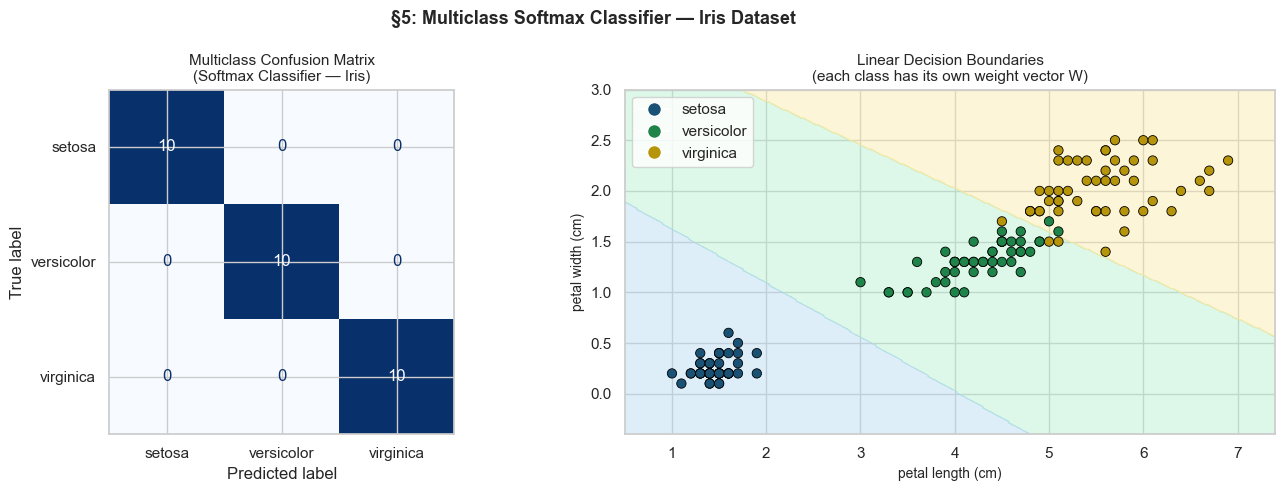

In [26]:
from matplotlib.colors import ListedColormap

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm_iris = confusion_matrix(y_te_i, y_pred_iris)
ConfusionMatrixDisplay(cm_iris, display_labels=iris.target_names).plot(
    ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title('Multiclass Confusion Matrix\n(Softmax Classifier — Iris)', fontsize=11)

# Linear decision boundaries on 2 features
feat_idx  = [2, 3]   # petal length, petal width
feat_names = [iris.feature_names[i] for i in feat_idx]
X_2d = X_iris.iloc[:, feat_idx].values
y_2d = y_iris.values

sc_2d = StandardScaler()
sc_2d.fit(X_2d)
X_2d_t = sc_2d.transform(X_2d)

clf_2d = LogisticRegression(
    multi_class='multinomial', C=mc_gs.best_params_['C'],
    solver='lbfgs', max_iter=2000
)
clf_2d.fit(X_2d_t, y_2d)

x0_min, x0_max = X_2d[:,0].min()-0.5, X_2d[:,0].max()+0.5
x1_min, x1_max = X_2d[:,1].min()-0.5, X_2d[:,1].max()+0.5
xx, yy = np.meshgrid(np.linspace(x0_min,x0_max,300),
                      np.linspace(x1_min,x1_max,300))
Z = clf_2d.predict(sc_2d.transform(np.c_[xx.ravel(), yy.ravel()])).reshape(xx.shape)

cmap_bg  = ListedColormap(['#AED6F1','#ABEBC6','#F9E79F'])
cmap_pts = ListedColormap(['#1A5276','#1E8449','#B7950B'])
axes[1].contourf(xx, yy, Z, alpha=0.40, cmap=cmap_bg)
axes[1].scatter(X_2d[:,0], X_2d[:,1], c=y_2d, cmap=cmap_pts,
                edgecolors='black', s=45, linewidths=0.6)
axes[1].set_xlabel(feat_names[0], fontsize=10)
axes[1].set_ylabel(feat_names[1], fontsize=10)
axes[1].set_title('Linear Decision Boundaries\n(each class has its own weight vector W)',
                   fontsize=11)
handles = [
    plt.Line2D([0],[0], marker='o', color='w',
                markerfacecolor=c, markersize=10, label=n)
    for c, n in zip(['#1A5276','#1E8449','#B7950B'], iris.target_names)
]
axes[1].legend(handles=handles)

plt.suptitle('§5: Multiclass Softmax Classifier — Iris Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Summary

### Key Takeaways from Module 1

| Concept | sklearn approach | PyTorch approach |
|---------|-----------------|------------------|
| **Linear equation** `Y = WXᵀ + w₀` | `LinearRegression` | `nn.Linear(n, 1)` |
| **Activation functions** | Built-in | `torch.sigmoid`, `torch.relu`, `torch.tanh` |
| **Input encoding / scaling** | `ColumnTransformer` | sklearn → `.fit_transform()` → `torch.tensor()` |
| **Linear Regression** | `LinearRegression()` | `nn.Linear` + `MSELoss` |
| **Ridge (L2)** | `Ridge(alpha=λ)` | `optim.Adam(..., weight_decay=λ)` |
| **Lasso (L1)** | `Lasso(alpha=λ)` | Manual `loss += λ · Σ\|w\|` |
| **ElasticNet** | `ElasticNet(alpha, l1_ratio)` | `weight_decay` (L2) + manual L1 penalty |
| **Hyperparameter tuning** | `GridSearchCV` | Manual K-Fold loop |
| **Regression metrics** | `r2_score`, `mean_squared_error` | sklearn (unchanged) |
| **Logistic Regression** | `LogisticRegression` | `nn.Linear(n,1)` + `BCEWithLogitsLoss` |
| **Confusion matrix / Report** | `ConfusionMatrixDisplay` | sklearn (unchanged) |
| **ROC curve + AUC** | `roc_curve`, `auc` | sklearn (unchanged) |
| **Softmax / Multinomial** | `LogisticRegression(multi_class='multinomial')` | `nn.Linear(n, K)` + `CrossEntropyLoss` |

### Connection to Deep Learning

```
Linear Regression    =  1 layer  +  identity activation
Logistic Regression  =  1 layer  +  sigmoid activation
Softmax Classifier   =  1 layer  +  softmax activation
Neural Network       =  N layers +  non-linear activations (ReLU, tanh …)
Deep Neural Network  =  many layers + non-linear activations
```

> "A linear activation function produces linear decisions **no matter the network size**.  
> Non-linearities allow us to approximate arbitrarily complex functions." — Slide 19